<a href="https://colab.research.google.com/github/nilotpal-makes-stuff/Python_TensorFlow-text_classification/blob/main/02Feed_Forward_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python TensorFlow - Text Classification

Python TensorFlow for Machine Learning – Neural Network Text Classification Tutorial FreeCodeCamp.
Youtube link - https://www.youtube.com/watch?v=VtRLrQ3Ev-U

## Feed Forward Network using Diabetes Dataset
A **Feed Forward Neural Network (FNN)** is an artificial neural network where information flows in a single direction from the input layer, through hidden layers, to the output layer without loops or feedback cycles. It is widely used for classification and regression tasks like image recognition, credit scoring, and pattern recognition.

Importing libraries into the notebook :


In [2]:
import pandas
import numpy
import matplotlib.pyplot as pyplot
import tensorflow


Import dataset into environment using the folder icon at left panel. Note that dataset gets removed after session ends in Google Colab. Dataset is sourced from National Institute of Diabetes and Digestive and Kidney Diseases(NIDDK). Data from NIDDK site can be requested using Researcher Auth Service(RAS).

dataset : https://drive.google.com/drive/folders/1YnxDqNIqM2Xr1Dlgv5pYsE6dYJ9MGxcM

In [4]:
diabetes_csv_file = "/content/diabetes.csv"
diabetes_df = pandas.read_csv(diabetes_csv_file)
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


This dataset contains data on Pima Native Indian Women who are atleast 21 years of age. The dataset contains 768 rows and 9 columns. Columns are :
* Pregnancies : Number of pregnancies
* Glucose : Plasma glucose concentration in an oral glucose tolerance test
* BloodPressure :  Diastolic blood pressure (mm Hg)
* SkinThickness :  Triceps skinfold thickness (mm)
* Insulin :  Two hour serum insulin
* BMI : Body Mass Index
* DiabetesPedigreeFunction :  Diabetes pedigree function
* Age : Age of person in years
* Outcome : 1 for Diabetic; 0 for non Diabetic

In [5]:
diabetes_df.shape

(768, 9)

We can check the distribution of the values of each variable in the dataset. This helps us understand how the data is distributed. We can also check summary of the column of the dataframe.

The descriptive statistics for the column 'Pregnancies' are as follows:
count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64


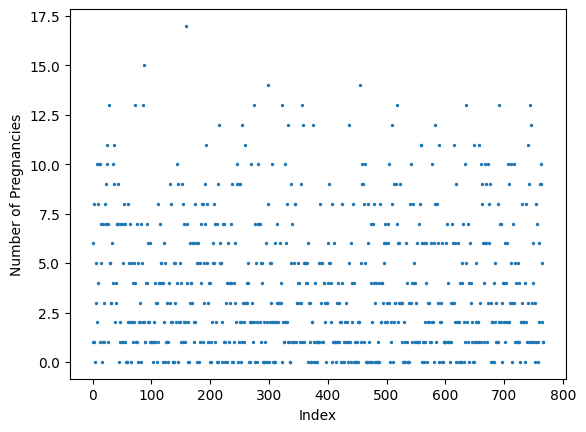

In [18]:
pyplot.scatter(diabetes_df.index, diabetes_df['Pregnancies'], s=2)
pyplot.xlabel("Index")
pyplot.ylabel("Number of Pregnancies")
print(f"The descriptive statistics for the column 'Pregnancies' are as follows:\n{diabetes_df['Pregnancies'].describe()}")

Some columns may require cleaning the data and working with missing values depending on the dataset. We can detect such columns if we know about the data that is stored in the column. For example in column 'BloodPressure' a value of 0 is missing data. This needs to be rectified if possible or rows containing those values need to be removed if we consider the column as an important variable in our study/research.

The descriptive statistics for the column 'BloodPressure' are as follows:
count    768.000000
mean      69.105469
std       19.355807
min        0.000000
25%       62.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64


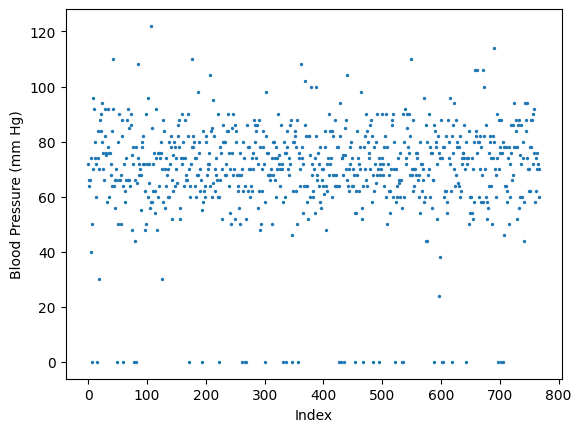

In [19]:
pyplot.scatter(diabetes_df.index, diabetes_df['BloodPressure'], s=2)
pyplot.xlabel("Index")
pyplot.ylabel("Blood Pressure (mm Hg)")
print(f"The descriptive statistics for the column 'BloodPressure' are as follows:\n{diabetes_df['BloodPressure'].describe()}")

As we can see there are missing values in this column and we need to deal with these values.

In [24]:
#Filter missing blood pressure rows
missing_bp = (diabetes_df['BloodPressure'] == 0 )
print(f"Number of entries with missing Blood pressure values = {len(diabetes_df[missing_bp])}")

Number of entries with missing Blood pressure values = 35


One way to explore data is to plot values of a column against the outcome to get an idea of the correlation between the variable the column depicts and the outcome. Lets plot histograms for each column in dataset vs the outcome column.

(0, 17) 20
X-axis = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0]
Y-axis for non diabetic people = [179 132  81  54  26  18  10   0   0]
Y-axis for diabetic people = [67 46 44 41 40 17  9  3  1]



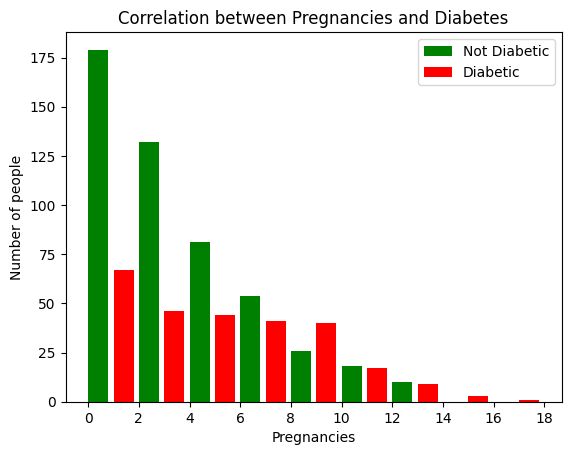

(0, 199) 200
X-axis = [0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0]
Y-axis for non diabetic people = [  3   0   4  31 143 157 100  44  12]
Y-axis for diabetic people = [ 2  0  0  1 13 54 63 51 49]



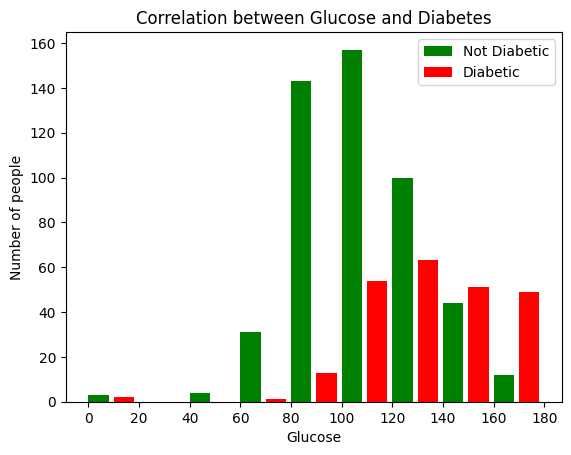

(0, 122) 130
X-axis = [0.0, 13.0, 26.0, 39.0, 52.0, 65.0, 78.0, 91.0, 104.0, 117.0]
Y-axis for non diabetic people = [ 19   1   2  18 134 183 123  15   4]
Y-axis for diabetic people = [16  0  1  7 38 99 89 11  7]



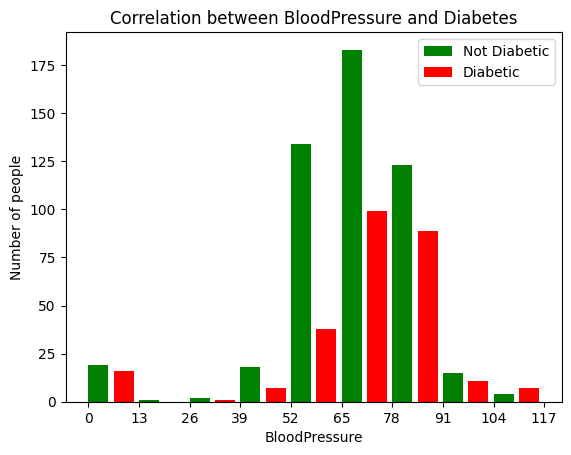

(0, 99) 100
X-axis = [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0]
Y-axis for non diabetic people = [142  93 117 100  40   7   1   0   0]
Y-axis for diabetic people = [89 14 48 75 38  2  1  0  0]



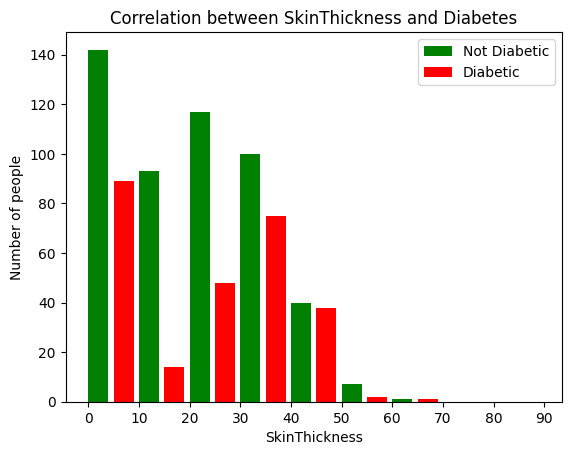

(0, 846) 850
X-axis = [0.0, 85.0, 170.0, 255.0, 340.0, 425.0, 510.0, 595.0, 680.0, 765.0]
Y-axis for non diabetic people = [340  99  34  16   5   3   1   0   2]
Y-axis for diabetic people = [147  56  36  14   3   6   4   1   0]



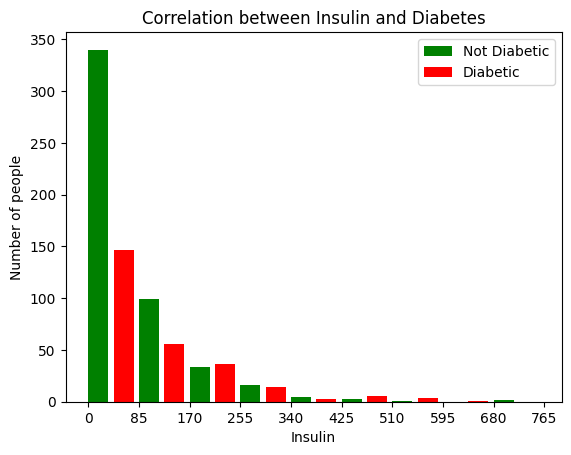

(0.0, 67.1) 70.0
X-axis = [0.0, 7.0, 14.0, 21.0, 28.0, 35.0, 42.0, 49.0, 56.0, 63.0]
Y-axis for non diabetic people = [  9   0  19 167 175 102  26   1   1]
Y-axis for diabetic people = [  2   0   0  27 121  71  37   8   1]



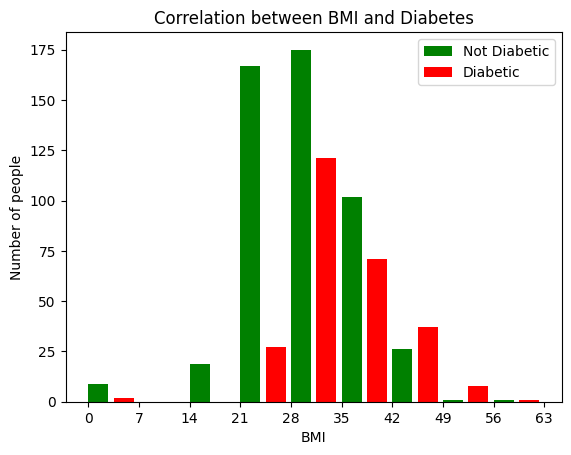

(0.078, 2.42) 3
X-axis = [0.078, 0.378, 0.6779999999999999, 0.9779999999999999, 1.278, 1.578, 1.878, 2.178, 2.4779999999999998, 2.7779999999999996]
Y-axis for non diabetic people = [273 144  60  13   4   5   0   1   0]
Y-axis for diabetic people = [114  74  51  17   8   0   2   2   0]



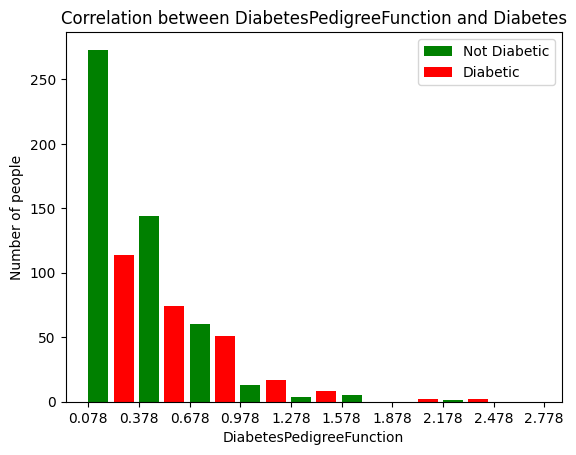

(21, 81) 70
X-axis = [21.0, 28.0, 35.0, 42.0, 49.0, 56.0, 63.0, 70.0, 77.0, 84.0]
Y-axis for non diabetic people = [271  91  55  35  15  16  15   1   1]
Y-axis for diabetic people = [61 65 53 43 29 13  3  1  0]



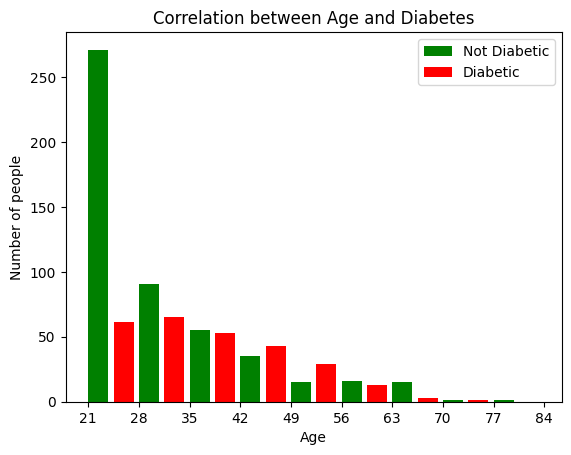

In [87]:
#Filters
diabetes_negative = (diabetes_df['Outcome'] == 0)
diabetes_positive = (diabetes_df['Outcome'] == 1)

#Plotting correlation
for i in range(len(diabetes_df.columns[:-1])) :
    column = diabetes_df.columns[i]
    #We classify data in columns into 10 buckets
    maxval = max(diabetes_df[column])
    minval = min(diabetes_df[column])

    #Round to nearest 10
    rounded_range = round(maxval-minval, -1)
    if rounded_range < maxval :
        rounded_range += 10
    #Round to nearest 1 if maximum value <=10
    if rounded_range <= 10 :
        rounded_range = round(maxval-minval)
        if rounded_range < maxval :
            rounded_range += 1
    print((minval,maxval), rounded_range)

    #Step size
    step=rounded_range/10

    #X-Axis
    xaxis = [minval + i*(step) for i in range(10)]
    print(f"X-axis = {xaxis}")
    xaxis_neg = [val-step for val in xaxis][1:]
    xaxis_pos = [val-0.5*step for val in xaxis][1:]

    #Y-Axis Negative
    #Bucket values using numpy.histogram
    count, edges = numpy.histogram(diabetes_df[diabetes_negative][column], bins=xaxis)
    yaxis_neg = count
    print(f"Y-axis for non diabetic people = {yaxis_neg}")

    count, edges = numpy.histogram(diabetes_df[diabetes_positive][column], bins=xaxis)
    yaxis_pos = count
    print(f"Y-axis for diabetic people = {yaxis_pos}")

    print()

    #Plot bar graph (Histogram)
    pyplot.bar(xaxis_neg, yaxis_neg, color='green', label='Not Diabetic', width=0.4*step, align='edge')
    pyplot.bar(xaxis_pos, yaxis_pos, color='red', label='Diabetic', width=0.4*step, align='edge')
    pyplot.title(f"Correlation between {column} and Diabetes")
    pyplot.xticks(xaxis)
    pyplot.xlabel(f"{column}")
    pyplot.ylabel("Number of people")
    pyplot.legend()
    pyplot.show()

In [86]:
#Verify data
less = (diabetes_df['Pregnancies'] < 2)
print(f"Number of Pregnancies for non Diabetic people = {len(diabetes_df[diabetes_negative & less]['Pregnancies'])}")
print(f"Number of Pregnancies for Diabetic people = {len(diabetes_df[diabetes_positive & less]['Pregnancies'])}")

Number of Pregnancies for non Diabetic people = 179
Number of Pregnancies for Diabetic people = 67
